In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import optimize, signal, integrate, special
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [2]:
R = 8.31446261815324  # J/mol.K
T0 = 292.05           # K
p0 = 101600           # Pa
V = 190e-6            # m3 of isopropanol
m = 2.7677            # g of Raney Nickel
rho = 785             # kg/m³
M = 60.1              # g/mol
n0 = 1000*rho*V/M     # mol

In [3]:
n0

2.4816971713810316

In [4]:
k = 8.765e-6
b = 8.901e5
a = 1.234e4

In [5]:
def model(t, x, k, a, b, n0):
    return np.array([
        k*(a*(n0 - x))/(a*(n0 - x) + b*x)
    ])

In [6]:
t = np.linspace(0, 10000, 1001)

In [7]:
sol = integrate.solve_ivp(model, [t.min(), t.max()], y0=[0], args=(k, a, b, n0), t_eval=t)

In [8]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e+01 ...  9.990e+03  1.000e+04]
        y: [[ 0.000e+00  8.754e-05 ...  5.029e-02  5.033e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 62
     njev: 0
      nlu: 0

In [9]:
xi = sol.y[0,:]

In [10]:
r = model(t, xi, k, a, b, n0).squeeze()

In [11]:
A = (n0 - xi)/V
B = xi/V

In [12]:
data = pd.DataFrame({"t": t, "xi": xi, "r": r, "A": A, "B": B})

In [13]:
def model(t, k1, k2):
    return np.real(n0 * (1 - k2 / (1 - k2) * special.lambertw((1 - k2) / k2 * np.exp(- k1 * t / (n0 * k2) + (1 - k2) / k2))))

In [14]:
popt, pcov = optimize.curve_fit(model, data["t"], data["xi"], p0=[1e-6, 10])

In [15]:
yhat = model(data["t"], *popt)

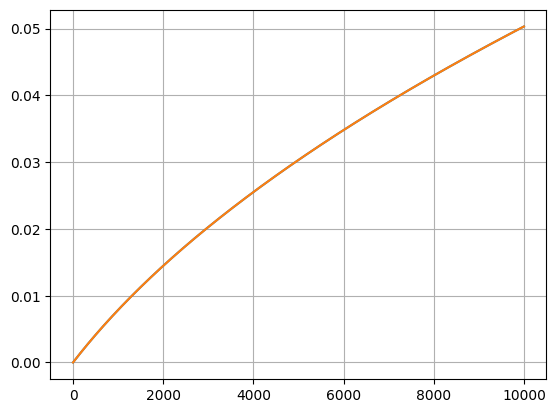

In [16]:
fig, axe = plt.subplots()
axe.plot(data["t"], data["xi"])
axe.plot(data["t"], yhat)
axe.grid()